In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, ScalarFormatter

In [2]:
# -------------------------------------------------------------------
# Global style: minimal, print-friendly
# -------------------------------------------------------------------
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
    "grid.linewidth": 0.4,
})

def thousands_formatter(x, pos):
    """Formatter that prints integers with thousands separator."""
    try:
        return f"{int(x):,}"
    except (ValueError, TypeError):
        return str(x)

def make_ax_minimal(ax, grid_y=True, comma_x=False, comma_y=False):
    """Minimal, print-friendly axis style, with optional comma formatting."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)
    if grid_y:
        ax.yaxis.grid(True, which="major", alpha=0.2)
    ax.tick_params(axis="both", which="both", length=3, width=0.6, direction="out")

    # y-axis: always numeric
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.yaxis.get_major_formatter().set_scientific(False)
    if comma_y:
        ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # x-axis: only touch if we explicitly want numeric formatting
    if comma_x:
        ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
        ax.xaxis.get_major_formatter().set_scientific(False)
        ax.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))


In [3]:
# -------------------------------------------------------------------
# BPIC configuration: includes 2016
# -------------------------------------------------------------------
bpic_order = [2014, 2016, 2017, 2019]
palette = sns.color_palette("colorblind", len(bpic_order))
bpic_labels = {
    2014: "BPIC 2014",
    2016: "BPIC 2016",
    2017: "BPIC 2017",
    2019: "BPIC 2019",
}

# -------------------------------------------------------------------
# Load data
# -------------------------------------------------------------------
calls_csv = "bpic_dummy_drill_unfold_calls.csv"
summary_csv = "bpic_dummy_drill_unfold_summary.csv"

df_calls = pd.read_csv(calls_csv)
df_summary = pd.read_csv(summary_csv)


In [4]:
# -------------------------------------------------------------------
# Per-year averages (read time and drill-down time, all n)
# -------------------------------------------------------------------
year_avg = (
    df_summary
    .groupby("Year", as_index=False)
    .agg({
        "Read time (s)": "mean",
        "Drilldown time (s)": "mean",
    })
    .rename(columns={
        "Read time (s)": "Read time avg (s)",
        "Drilldown time (s)": "Drilldown time avg (s)",
    })
)

# -------------------------------------------------------------------
# One row per log (Year/File), plus per-year averages
# -------------------------------------------------------------------
summary_unique = (
    df_summary
    .drop_duplicates(subset=["Year", "File"])
    .sort_values("Year")
    .copy()
)

summary_unique = summary_unique.merge(
    year_avg[["Year", "Read time avg (s)", "Drilldown time avg (s)"]],
    on="Year",
    how="left",
)

summary_unique["BPIC"] = summary_unique["Year"].map(bpic_labels)

# Focus on n_categories = 10
n_focus = 10
df_calls_n = df_calls[df_calls["n_categories"] == n_focus].copy()
df_summary_n = (
    df_summary[df_summary["n_categories"] == n_focus]
    .drop_duplicates(subset=["Year", "File"])
    .sort_values("Year")
    .copy()
)
df_summary_n["BPIC"] = df_summary_n["Year"].map(bpic_labels)

# Per-year averages for read & drill at n = 10 (for figs 4, 6, 7)
df_n_avg = (
    df_summary_n
    .groupby("Year", as_index=False)
    .agg({
        "Num events": "mean",
        "Num objects": "mean",
        "Read time (s)": "mean",
        "Drilldown time (s)": "mean",
    })
    .rename(columns={
        "Read time (s)": "Read time avg (s)",
        "Drilldown time (s)": "Drilldown time avg (s)",
    })
)
df_n_avg["BPIC"] = df_n_avg["Year"].map(bpic_labels)

# Enforce BPIC order as categorical
cat_order = [bpic_labels[y] for y in bpic_order]
summary_unique["BPIC"] = pd.Categorical(summary_unique["BPIC"],
                                        categories=cat_order,
                                        ordered=True)
df_summary_n["BPIC"] = pd.Categorical(df_summary_n["BPIC"],
                                      categories=cat_order,
                                      ordered=True)
df_n_avg["BPIC"] = pd.Categorical(df_n_avg["BPIC"],
                                  categories=cat_order,
                                  ordered=True)


In [5]:
# -------------------------------------------------------------------
# 1. Descriptive table (for the paper text)
#    includes per-year averages for read and drill-down times
# -------------------------------------------------------------------
display(
    summary_unique[
        [
            "BPIC",
            "Num events",
            "Num objects",
            "Num relations",
            "Read time avg (s)",
            "Unfold avg per call (s)",
            "Drilldown time avg (s)",
        ]
    ]
)


,BPIC,Num events,Num objects,Num relations,Read time avg (s),Unfold avg per call (s),Drilldown time avg (s)
0,BPIC 2014,690622,228885,2732213,34.702561,1.428215,3.554894
1,BPIC 2016,7360146,748913,36430880,659.884105,29.778024,59.974073
2,BPIC 2017,1202267,106162,2404534,48.804297,1.654738,2.930379
3,BPIC 2019,1595923,330685,5984602,80.220696,3.215930,8.182408


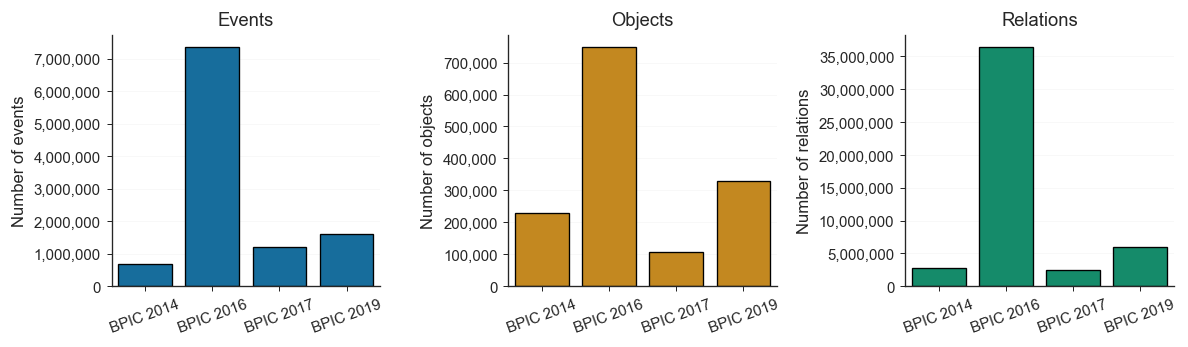

In [6]:
# -------------------------------------------------------------------
# 2. Three bar charts: events / objects / relations per log
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True)

bar_kwargs = dict(
    data=summary_unique,
    x="BPIC",
    order=cat_order,
    edgecolor="black",
)

sns.barplot(y="Num events", ax=axes[0], color=palette[0], **bar_kwargs)
axes[0].set_ylabel("Number of events")
axes[0].set_xlabel("")
axes[0].set_title("Events")

sns.barplot(y="Num objects", ax=axes[1], color=palette[1], **bar_kwargs)
axes[1].set_ylabel("Number of objects")
axes[1].set_xlabel("")
axes[1].set_title("Objects")

sns.barplot(y="Num relations", ax=axes[2], color=palette[2], **bar_kwargs)
axes[2].set_ylabel("Number of relations")
axes[2].set_xlabel("")
axes[2].set_title("Relations")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)
    make_ax_minimal(ax, grid_y=True, comma_y=True)

fig.tight_layout()
fig.savefig("fig01_log_sizes_bpic.pdf", bbox_inches="tight")
plt.show()


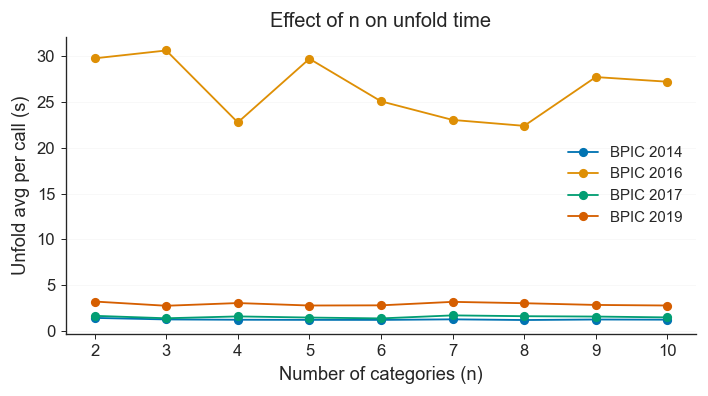

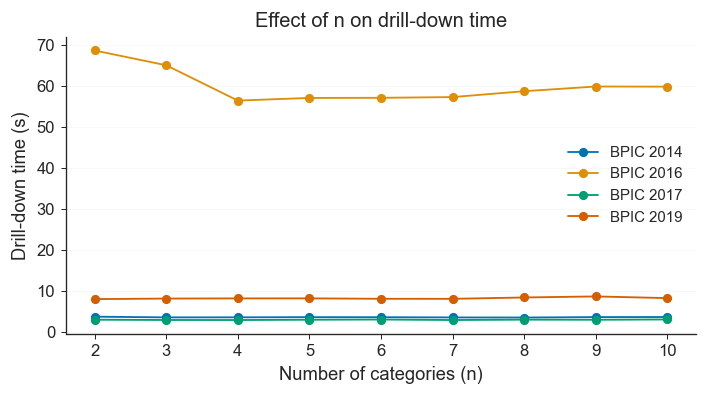

In [7]:
# -------------------------------------------------------------------
# 3. Effect of changing n on unfold and drill-down (by log)
# -------------------------------------------------------------------
df_grp = (
    df_summary
    .groupby(["Year", "n_categories"], as_index=False)
    .agg(
        {
            "Unfold avg per call (s)": "mean",
            "Drilldown time (s)": "mean",
        }
    )
)
df_grp["BPIC"] = df_grp["Year"].map(bpic_labels)

# 3a. Unfold avg per call vs n_categories
fig, ax = plt.subplots(figsize=(6, 3.4))

for i, y in enumerate(bpic_order):
    sub = df_grp[df_grp["Year"] == y].sort_values("n_categories")
    if sub.empty:
        continue
    ax.plot(
        sub["n_categories"],
        sub["Unfold avg per call (s)"],
        marker="o",
        markersize=4.5,
        linewidth=1.1,
        color=palette[i],
        label=bpic_labels[y],
    )

ax.set_xlabel("Number of categories (n)", fontsize=11)
ax.set_ylabel("Unfold avg per call (s)", fontsize=11)
ax.set_title("Effect of n on unfold time", fontsize=12)
ax.tick_params(axis="both", labelsize=10)
make_ax_minimal(ax, grid_y=True)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig("fig02_effect_n_unfold.pdf", bbox_inches="tight")
plt.show()

# 3b. Drilldown time vs n_categories
fig, ax = plt.subplots(figsize=(6, 3.4))

for i, y in enumerate(bpic_order):
    sub = df_grp[df_grp["Year"] == y].sort_values("n_categories")
    if sub.empty:
        continue
    ax.plot(
        sub["n_categories"],
        sub["Drilldown time (s)"],
        marker="o",
        markersize=4.5,
        linewidth=1.1,
        color=palette[i],
        label=bpic_labels[y],
    )

ax.set_xlabel("Number of categories (n)", fontsize=11)
ax.set_ylabel("Drill-down time (s)", fontsize=11)
ax.set_title("Effect of n on drill-down time", fontsize=12)
ax.tick_params(axis="both", labelsize=10)
make_ax_minimal(ax, grid_y=True)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig("fig03_effect_n_drilldown.pdf", bbox_inches="tight")
plt.show()


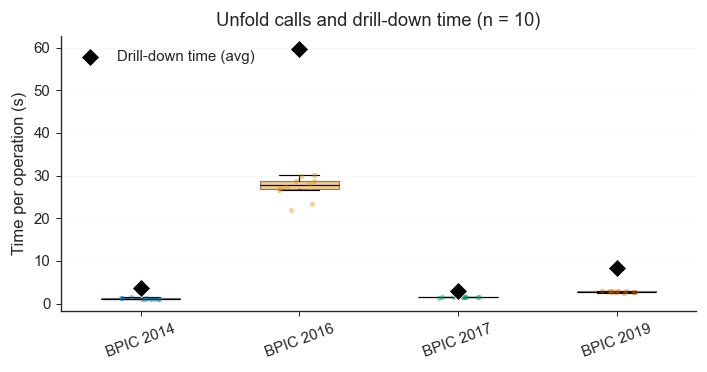

In [8]:
# -------------------------------------------------------------------
# 4. Detailed distribution for n = 10:
#    boxplot of unfold calls per BPIC + per-year avg drill-down times
# -------------------------------------------------------------------
year_order = bpic_order
x_pos = np.arange(1, len(year_order) + 1)

box_data = [
    df_calls_n.loc[df_calls_n["Year"] == y, "Unfold dt (s)"].dropna().values
    for y in year_order
]

# per-year avg drill-down time at n=10
drill_times_n = (
    df_n_avg.set_index("Year")
    .loc[year_order, "Drilldown time avg (s)"]
    .values
)

fig, ax = plt.subplots(figsize=(6, 3.2))

bp = ax.boxplot(
    box_data,
    positions=x_pos,
    widths=0.5,
    showfliers=False,
    patch_artist=True,
    zorder=1,
)

for patch, color in zip(bp["boxes"], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.7)

for element in ["whiskers", "caps", "medians"]:
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(0.7)

rng = np.random.default_rng(seed=0)
for i, y in enumerate(year_order, start=1):
    yvals = df_calls_n.loc[df_calls_n["Year"] == y, "Unfold dt (s)"].dropna().values
    if len(yvals) == 0:
        continue
    jitter = rng.uniform(-0.13, 0.13, size=len(yvals))
    ax.scatter(
        np.full_like(yvals, i, dtype=float) + jitter,
        yvals,
        s=10,
        alpha=0.4,
        linewidths=0,
        color=palette[i-1],
        zorder=2,
    )

ax.scatter(
    x_pos,
    drill_times_n,
    s=60,
    marker="D",
    color="black",
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
    label="Drill-down time (avg)",
)

ax.set_xticks(x_pos)
ax.set_xticklabels([bpic_labels[y] for y in year_order], rotation=20)
ax.set_xlabel("")
ax.set_ylabel("Time per operation (s)")
ax.set_title(f"Unfold calls and drill-down time (n = {n_focus})")
make_ax_minimal(ax, grid_y=True)
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
fig.savefig(f"fig04_unfold_distribution_n{n_focus}.pdf", bbox_inches="tight")
plt.show()


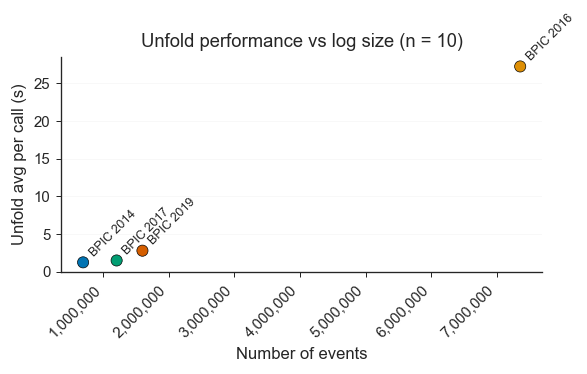

In [9]:
# -------------------------------------------------------------------
# helper: put text just above and slightly to the right of a point
# -------------------------------------------------------------------
def text_tight_above(ax, x, y, s, dx_pixels=4, dy_pixels=5, rotation=45, **kwargs):
    """Place text s just above (x, y) with a small pixel offset."""
    x_disp, y_disp = ax.transData.transform((x, y))
    x_disp += dx_pixels
    y_disp += dy_pixels
    x_data, y_data = ax.transData.inverted().transform((x_disp, y_disp))
    ax.text(
        x_data,
        y_data,
        s,
        ha="left",
        va="bottom",
        rotation=rotation,
        fontsize=7.5,
        **kwargs,
    )

# -------------------------------------------------------------------
# 5. Relation between number of events and unfold performance (n = 10)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3.2))

sns.scatterplot(
    data=df_summary_n,
    x="Num events",
    y="Unfold avg per call (s)",
    hue="BPIC",
    palette=palette,
    hue_order=cat_order,
    s=45,
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    legend=False,
)

ax.set_xlabel("Number of events")
ax.set_ylabel("Unfold avg per call (s)")
ax.set_title(f"Unfold performance vs log size (n = {n_focus})")
make_ax_minimal(ax, grid_y=True, comma_x=True, comma_y=False)

for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

for _, r in df_summary_n.iterrows():
    text_tight_above(
        ax,
        r["Num events"],
        r["Unfold avg per call (s)"],
        r["BPIC"],
        dx_pixels=4,
        dy_pixels=5,
        rotation=45,
    )

fig.tight_layout()
fig.savefig(f"fig05_unfold_vs_events_n{n_focus}.pdf", bbox_inches="tight")
plt.show()


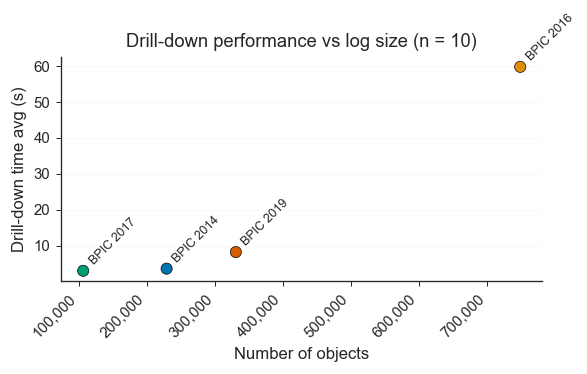

In [10]:
# -------------------------------------------------------------------
# 6. Relation between number of objects and drill-down performance (n = 10)
#     (per-year avg drill-down time)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3.2))

sns.scatterplot(
    data=df_n_avg,
    x="Num objects",
    y="Drilldown time avg (s)",
    hue="BPIC",
    palette=palette,
    hue_order=cat_order,
    s=45,
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    legend=False,
)

ax.set_xlabel("Number of objects")
ax.set_ylabel("Drill-down time avg (s)")
ax.set_title(f"Drill-down performance vs log size (n = {n_focus})")
make_ax_minimal(ax, grid_y=True, comma_x=True, comma_y=False)

for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

for _, r in df_n_avg.iterrows():
    text_tight_above(
        ax,
        r["Num objects"],
        r["Drilldown time avg (s)"],
        r["BPIC"],
        dx_pixels=4,
        dy_pixels=5,
        rotation=45,
    )

fig.tight_layout()
fig.savefig(f"fig06_drilldown_vs_objects_n{n_focus}.pdf", bbox_inches="tight")
plt.show()

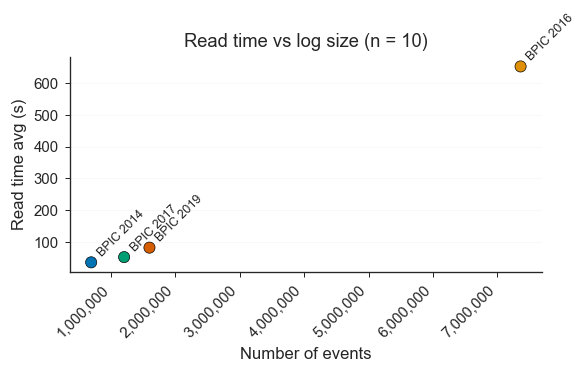

In [11]:
# -------------------------------------------------------------------
# 7. Relation between number of events and read time (n = 10)
#     (per-year avg read time)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 3.2))

sns.scatterplot(
    data=df_n_avg,
    x="Num events",
    y="Read time avg (s)",
    hue="BPIC",
    palette=palette,
    hue_order=cat_order,
    s=45,
    ax=ax,
    edgecolor="black",
    linewidth=0.4,
    legend=False,
)

ax.set_xlabel("Number of events")
ax.set_ylabel("Read time avg (s)")
ax.set_title(f"Read time vs log size (n = {n_focus})")
make_ax_minimal(ax, grid_y=True, comma_x=True, comma_y=False)

for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_ha("right")

for _, r in df_n_avg.iterrows():
    text_tight_above(
        ax,
        r["Num events"],
        r["Read time avg (s)"],
        r["BPIC"],
        dx_pixels=4,
        dy_pixels=5,
        rotation=45,
    )

fig.tight_layout()
fig.savefig(f"fig07_readtime_vs_events_n{n_focus}.pdf", bbox_inches="tight")
plt.show()